# BehaviorSpace Experiment 2 Analysis
Reward magnitude × duration

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
CSV_PATH=Path("./experiments/e2-duration/table.csv")
df=pd.read_csv(CSV_PATH, skiprows=6)
df.head()

,[run number],number-of-shoppers,reward-cycles,reward-duration,withdrawal-duration,low-reward-salience,high-reward-salience,[step],"choice-rate ""control"" ""baseline""","choice-rate ""low-salience"" ""baseline""",...,"mean-intrinsic-motivation ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience""",high-reward-crowding-out-effect,low-reward-persistence-effect,high-reward-withdrawal-drop,low-reward-withdrawal-drop,high-reward-retention-ratio,low-reward-retention-ratio
0,9,1000,1,20,80,0.15,0.55,130,0.374152,0.371171,...,0.518206,0.425150,0.442943,0.428979,0.023444,0.035718,0.245008,0.040541,0.643723,0.918182
1,2,1000,1,20,80,0.15,0.55,130,0.372156,0.371672,...,0.519413,0.415569,0.455856,0.445345,0.036840,0.036239,0.249925,0.049024,0.645172,0.902508
2,4,1000,1,20,80,0.15,0.55,130,0.378643,0.377477,...,0.509967,0.413623,0.462312,0.418769,0.020787,0.037379,0.254279,0.041592,0.635257,0.916991
3,8,1000,1,20,80,0.15,0.55,130,0.368663,0.388889,...,0.538362,0.403144,0.456456,0.426426,0.040558,0.067848,0.261149,0.038814,0.630968,0.924282
4,7,1000,1,20,80,0.15,0.55,130,0.383733,0.372873,...,0.517605,0.426347,0.450751,0.426426,0.024108,0.034769,0.250563,0.046359,0.636913,0.906637


In [2]:
metrics={
'choice-rate "high-salience" "reward"':'reward_choice_rate',
'persistence "high-salience"':'persistence',
'persistence-index "high-salience"':'persistence_index',
'mean-intrinsic-motivation "high-salience"':'intrinsic_motivation',
'mean-habit "high-salience"':'habit_strength',
'high-reward-crowding-out-effect':'motivation_gap'}
a=df.rename(columns=metrics)
summary=a.groupby(['reward-duration','high-reward-salience'])[list(metrics.values())].mean().reset_index()
summary

,reward-duration,high-reward-salience,reward_choice_rate,persistence,persistence_index,intrinsic_motivation,habit_strength,motivation_gap
0,20,0.55,0.697092,0.442750,0.066544,0.517382,0.424044,0.026121
1,20,0.65,0.736416,0.437208,0.059187,0.489250,0.414995,0.023788
2,20,0.75,0.773143,0.433845,0.055530,0.471039,0.406722,0.019078
3,20,0.85,0.805671,0.426491,0.050969,0.453291,0.398218,0.010597
4,20,0.95,0.834850,0.421225,0.047845,0.429571,0.390440,0.006413
5,40,0.55,0.729227,0.454318,0.075449,0.536070,0.431877,0.038552
6,40,0.65,0.761542,0.433330,0.057220,0.479537,0.406041,0.017831
7,40,0.75,0.798961,0.426548,0.047042,0.442922,0.397107,0.008867
8,40,0.85,0.830330,0.418860,0.041192,0.406352,0.386887,0.004370
9,40,0.95,0.857420,0.408114,0.028605,0.372390,0.373899,-0.006062


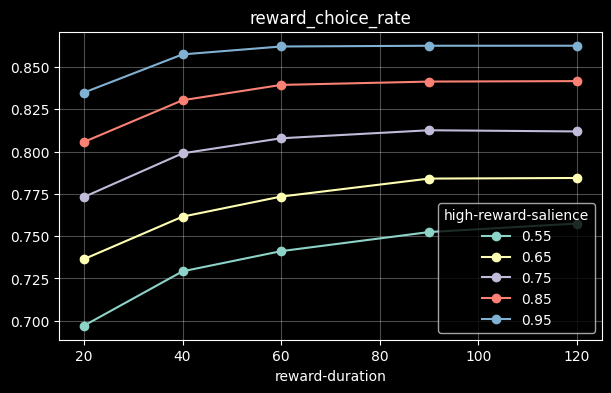

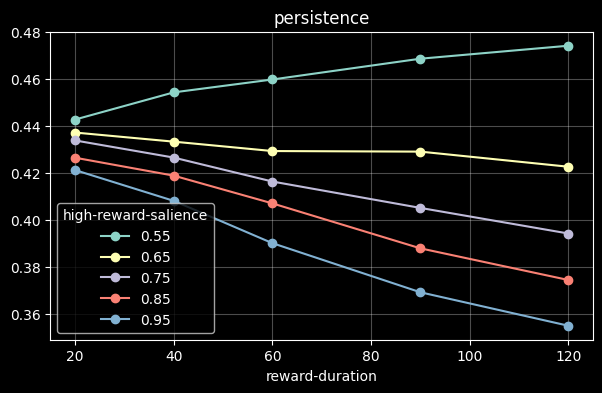

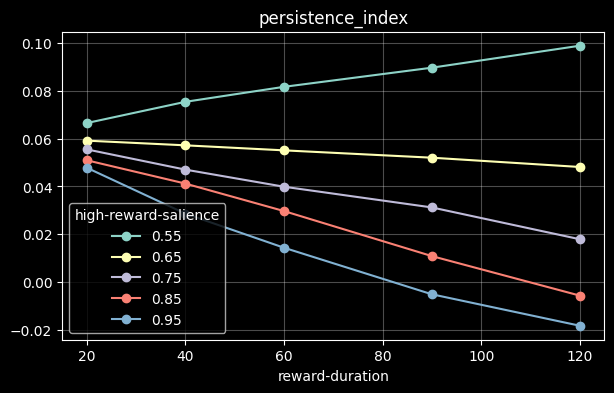

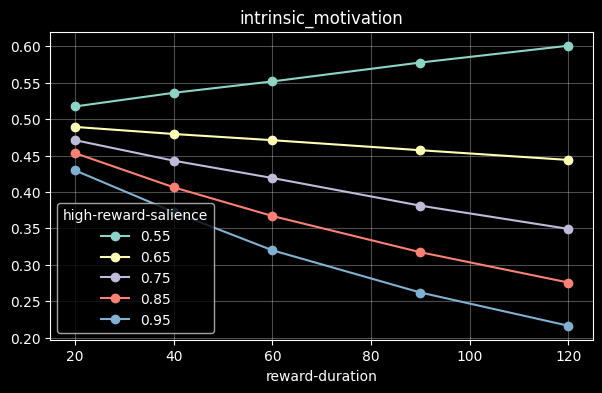

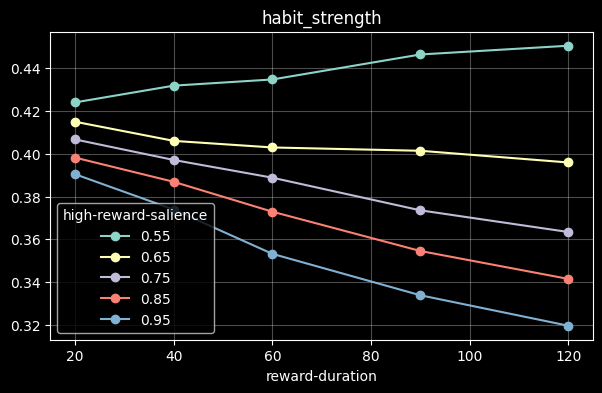

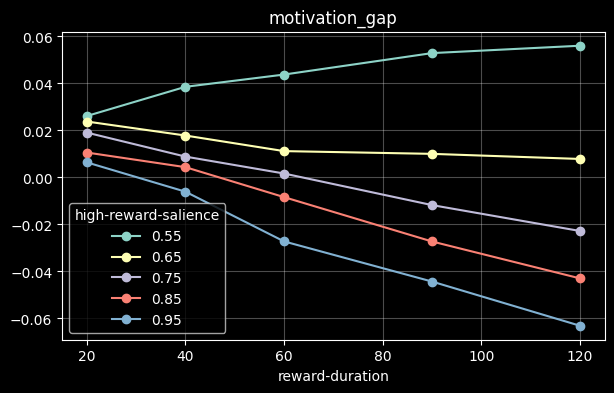

In [3]:
for m in ['reward_choice_rate','persistence','persistence_index','intrinsic_motivation','habit_strength','motivation_gap']:
    piv=summary.pivot(index='reward-duration',columns='high-reward-salience',values=m)
    ax=piv.plot(marker='o',figsize=(7,4),title=m)
    ax.grid(True,alpha=.3)
    plt.show()

In [4]:
# Two-way descriptive table
summary.to_csv('experiment2_summary.csv',index=False)
summary

,reward-duration,high-reward-salience,reward_choice_rate,persistence,persistence_index,intrinsic_motivation,habit_strength,motivation_gap
0,20,0.55,0.697092,0.442750,0.066544,0.517382,0.424044,0.026121
1,20,0.65,0.736416,0.437208,0.059187,0.489250,0.414995,0.023788
2,20,0.75,0.773143,0.433845,0.055530,0.471039,0.406722,0.019078
3,20,0.85,0.805671,0.426491,0.050969,0.453291,0.398218,0.010597
4,20,0.95,0.834850,0.421225,0.047845,0.429571,0.390440,0.006413
5,40,0.55,0.729227,0.454318,0.075449,0.536070,0.431877,0.038552
6,40,0.65,0.761542,0.433330,0.057220,0.479537,0.406041,0.017831
7,40,0.75,0.798961,0.426548,0.047042,0.442922,0.397107,0.008867
8,40,0.85,0.830330,0.418860,0.041192,0.406352,0.386887,0.004370
9,40,0.95,0.857420,0.408114,0.028605,0.372390,0.373899,-0.006062
